#### ***Ensemble Learning***

- ***Ensemble Learning combines multiple Machine Learning models (called base learners) to create one stronger model.***

- ***Types of Ensemble Learning***
    - Bagging 
    - Boosting 
    - Voting 
    - Stacking

---

- ***Bagging***
   - ***Bagging trains multiple models independently on different bootstrap samples and combines their predictions to reduce variance.***

   -  ***Random Forest & Extra Tree is the most common example.***

In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.shape

(891, 15)

In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
features = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

from sklearn.impute import SimpleImputer
# Handling Missing Value 
age_imputer = SimpleImputer(strategy="median")
df[["age"]] = age_imputer.fit_transform(df[['age']])

embarked_imputer = SimpleImputer(strategy="most_frequent")
df[["embarked"]] = embarked_imputer.fit_transform(df[["embarked"]])

deck_imputer = SimpleImputer(strategy="most_frequent")
df[["deck"]] = deck_imputer.fit_transform(df[["deck"]])

In [6]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    2
alive          0
alone          0
dtype: int64

In [7]:
from sklearn.preprocessing import  LabelEncoder

le= LabelEncoder()
df['sex'] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])

In [8]:
features = ["pclass","sex","fare","embarked","age"]
df[features].head()

,pclass,sex,fare,embarked,age
0,3,1,7.2500,2,22.0
1,1,0,71.2833,0,38.0
2,3,0,7.9250,2,26.0
3,1,0,53.1000,2,35.0
4,3,1,8.0500,2,35.0


In [9]:
X = df[features]
y = df['survived']

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
     X,y,test_size=0.3,random_state=42
)

In [10]:
X_train.shape

(623, 5)

In [11]:
X_test.shape

(268, 5)

In [12]:
# Bagging For Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

# Train Our Model 
base_model = DecisionTreeClassifier(
     random_state=42,
     max_depth=7
)

model = BaggingClassifier(
     base_model,
     n_estimators=107,
     random_state=42,
     bootstrap=True
)
model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",107
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [13]:
# Test Prediction
y_pred = model.predict(X_test)

from sklearn.metrics import  accuracy_score,f1_score

print(f'accuracy score: {accuracy_score(y_test,y_pred)*100}%')
print(f'f1 score: {f1_score(y_test,y_pred)*100}%')

accuracy score: 80.97014925373134%
f1 score: 74.37185929648241%


In [14]:
# Train Prediction
test_pred = model.predict(X_train)

from sklearn.metrics import  accuracy_score,f1_score
print(f'accuracy score: {accuracy_score(y_train,test_pred)*100}%')
print(f'f1 score: {f1_score(y_train,test_pred)*100}%')

accuracy score: 91.17174959871589%
f1 score: 86.87350835322196%


In [15]:
# Bagging For Regression 
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression()

model = BaggingClassifier(
     base_model,
     n_estimators=107,
)
model.fit(X_train,y_train)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",LogisticRegression()
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",107
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [16]:
# Train Prediction
test_pred = model.predict(X_train)

from sklearn.metrics import  accuracy_score,f1_score
print(f'accuracy score: {accuracy_score(y_train,test_pred)*100}%')
print(f'f1 score: {f1_score(y_train,test_pred)*100}%')

accuracy score: 79.29373996789727%
f1 score: 71.52317880794702%


In [17]:
# Test Prediction
y_pred = model.predict(X_test)

from sklearn.metrics import  accuracy_score,f1_score

print(f'accuracy score: {accuracy_score(y_test,y_pred)*100}%')
print(f'f1 score: {f1_score(y_test,y_pred)*100}%')

accuracy score: 79.47761194029852%
f1 score: 74.88584474885845%


---

- ***Random Forest***
   - ***Random Forest is an ensemble learning algorithm that builds multiple decision trees using bootstrap sampling and random feature selection.***
   
   -  ***Each tree makes its own prediction, and the final prediction is obtained using majority voting for classification or averaging for regression.*** 

   - ***Compared to a single decision tree, Random Forest reduces overfitting and provides higher accuracy.***

In [18]:
## Decision Tree Model (no pruning)
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
     random_state=42,
     max_depth=9,
     min_samples_leaf=10,
     min_samples_split=100
)
model.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [19]:
from sklearn.metrics import accuracy_score
y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

## Evaluation
print("Training Accuracy:",accuracy_score(y_train,y_pred_train)*100,"%")
print("Testing Accuracy:",accuracy_score(y_test,y_pred_test)*100,"%")

Training Accuracy: 82.34349919743178 %
Testing Accuracy: 80.97014925373134 %


[Text(0.5, 0.95, 'sex <= 0.5\ngini = 0.467\nsamples = 623\nvalue = [392, 231]\nclass = Died'),
 Text(0.3076923076923077, 0.85, 'pclass <= 2.5\ngini = 0.396\nsamples = 213\nvalue = [58, 155]\nclass = Survived'),
 Text(0.40384615384615385, 0.8999999999999999, 'True  '),
 Text(0.15384615384615385, 0.75, 'fare <= 149.035\ngini = 0.07\nsamples = 110\nvalue = [4, 106]\nclass = Survived'),
 Text(0.07692307692307693, 0.65, 'gini = 0.04\nsamples = 97\nvalue = [2, 95]\nclass = Survived'),
 Text(0.23076923076923078, 0.65, 'gini = 0.26\nsamples = 13\nvalue = [2, 11]\nclass = Survived'),
 Text(0.46153846153846156, 0.75, 'fare <= 23.35\ngini = 0.499\nsamples = 103\nvalue = [54, 49]\nclass = Died'),
 Text(0.38461538461538464, 0.65, 'gini = 0.492\nsamples = 85\nvalue = [37, 48]\nclass = Survived'),
 Text(0.5384615384615384, 0.65, 'gini = 0.105\nsamples = 18\nvalue = [17, 1]\nclass = Died'),
 Text(0.6923076923076923, 0.85, 'age <= 6.5\ngini = 0.302\nsamples = 410\nvalue = [334, 76]\nclass = Died'),
 Te

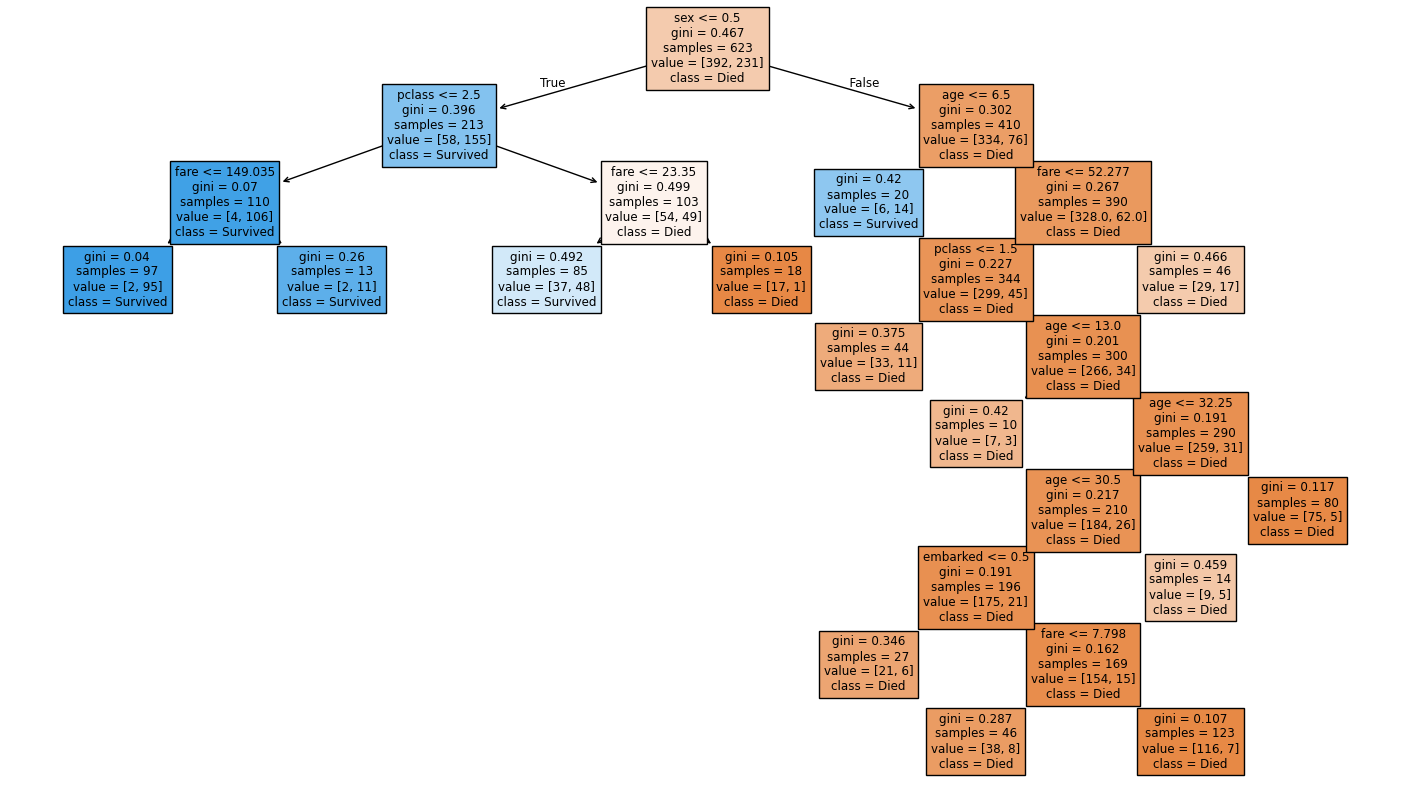

In [20]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
     model,
     feature_names=X.columns,
     class_names = ["Died","Survived"],
     filled=True,
)

In [21]:
# RandomForest For Classification 
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
     n_estimators = 177,
     oob_score=True,
     max_depth=5,
     min_samples_split=20
)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",177
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if 

In [22]:
y_pred = rf.predict(X_test)
t_pred = rf.predict(X_train)

print(f"Train Accuracy: {accuracy_score(y_train,t_pred)*100}%")
print(f"Test Accuracy: {accuracy_score(y_test,y_pred)*100}%")

Train Accuracy: 86.35634028892456%
Test Accuracy: 80.97014925373134%


In [23]:
print("OOB Score:",rf.oob_score_)

OOB Score: 0.8170144462279294


[Text(0.5, 0.95, 'sex <= 0.5\ngini = 0.467\nsamples = 623\nvalue = [392, 231]\nclass = Died'),
 Text(0.3076923076923077, 0.85, 'pclass <= 2.5\ngini = 0.396\nsamples = 213\nvalue = [58, 155]\nclass = Survived'),
 Text(0.40384615384615385, 0.8999999999999999, 'True  '),
 Text(0.15384615384615385, 0.75, 'fare <= 149.035\ngini = 0.07\nsamples = 110\nvalue = [4, 106]\nclass = Survived'),
 Text(0.07692307692307693, 0.65, 'gini = 0.04\nsamples = 97\nvalue = [2, 95]\nclass = Survived'),
 Text(0.23076923076923078, 0.65, 'gini = 0.26\nsamples = 13\nvalue = [2, 11]\nclass = Survived'),
 Text(0.46153846153846156, 0.75, 'fare <= 23.35\ngini = 0.499\nsamples = 103\nvalue = [54, 49]\nclass = Died'),
 Text(0.38461538461538464, 0.65, 'gini = 0.492\nsamples = 85\nvalue = [37, 48]\nclass = Survived'),
 Text(0.5384615384615384, 0.65, 'gini = 0.105\nsamples = 18\nvalue = [17, 1]\nclass = Died'),
 Text(0.6923076923076923, 0.85, 'age <= 6.5\ngini = 0.302\nsamples = 410\nvalue = [334, 76]\nclass = Died'),
 Te

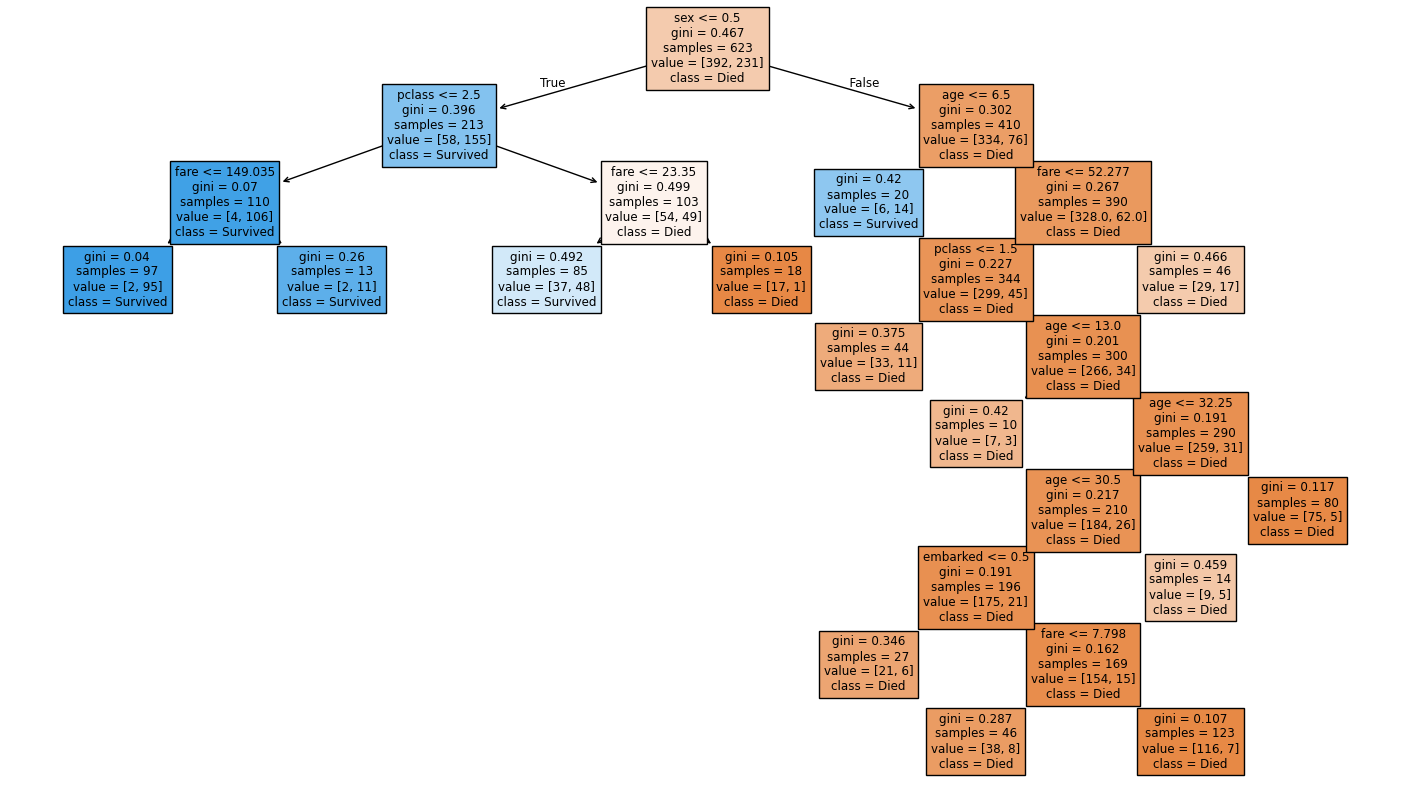

In [24]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
     model,
     feature_names=X.columns,
     class_names = ["Died","Survived"],
     filled=True,
)

In [25]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(importance.sort_values(by="Importance", ascending=False))

    Feature  Importance
1       sex    0.599158
0    pclass    0.194433
4       age    0.101195
2      fare    0.099188
3  embarked    0.006026


In [26]:
from sklearn.ensemble import ExtraTreesClassifier

ex_clf = ExtraTreesClassifier(
    n_estimators=107,
    random_state=42
)

model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",100
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [27]:
y_pred = rf.predict(X_test)
t_pred = rf.predict(X_train)

print(f"Train Accuracy: {accuracy_score(y_train,t_pred)*100}%")
print(f"Test Accuracy: {accuracy_score(y_test,y_pred)*100}%")

Train Accuracy: 86.35634028892456%
Test Accuracy: 80.97014925373134%


In [28]:
## RandomForest For Regression

import pandas as pd 
import seaborn as sns 
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()

## Convert Into DataFrame
df = pd.DataFrame(
    california.data,
    columns=california.feature_names
)

# add target column
df["MedHouseValue"] = california.target

In [29]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [30]:
df.shape

(20640, 9)

In [31]:
df.isnull().sum()

MedInc           0
HouseAge         0
AveRooms         0
AveBedrms        0
Population       0
AveOccup         0
Latitude         0
Longitude        0
MedHouseValue    0
dtype: int64

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MedInc         20640 non-null  float64
 1   HouseAge       20640 non-null  float64
 2   AveRooms       20640 non-null  float64
 3   AveBedrms      20640 non-null  float64
 4   Population     20640 non-null  float64
 5   AveOccup       20640 non-null  float64
 6   Latitude       20640 non-null  float64
 7   Longitude      20640 non-null  float64
 8   MedHouseValue  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [33]:
X = df.drop('MedHouseValue',axis=1)
Y = df['MedHouseValue']

In [46]:
from sklearn.model_selection import train_test_split

## Train Test Split
X_train,X_test,y_train,y_test = train_test_split(
     X,Y,test_size=0.3,random_state=42
)

In [47]:
X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45


In [48]:
from sklearn.ensemble import  RandomForestRegressor

rf_regressor = RandomForestRegressor(
     n_estimators=200,
     random_state=42
)
rf_regressor.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [52]:
from sklearn.metrics import mean_absolute_error, r2_score

test_pred = rf_regressor.predict(X_test)
train_pred = rf_regressor.predict(X_train)

print("Test MAE :", mean_absolute_error(y_test, test_pred))
print("Train MAE:", mean_absolute_error(y_train, train_pred))

Test MAE : 0.33038307902939307
Train MAE: 0.12309921814784114


In [53]:
print("Test R2 :", r2_score(y_test, test_pred)*100)
print("Train R2:", r2_score(y_train, train_pred)*100)

Test R2 : 80.67461283527786
Train R2: 97.32649098655611


---
#### ***Boosting***